# Function 3 - Separate Notebook (Noisy Objective)

We are separating **Function 3** because its objective appears noisy, and we want to try a different Bayesian approach without coupling that work to the other functions. Isolating it makes it easier to inspect the data and iterate on modeling choices.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

import sys
sys.path.append('../..')  # Go up two levels to project root

import importlib
import scripts.utils.data_utils as data_utils
importlib.reload(data_utils)

# Import utility functions
from scripts.utils.data_utils import (
    load_initial_data,
    load_week1_data,
    load_week2_data,
    load_week3_data,
    load_week4_data,
    _load_latest_week_data,
    plot_2d_scatter_with_distribution,
    plot_3d_scatter_with_distribution,
    plot_tsne_with_distribution,
)

# Import noise-aware Bayesian Optimization for function_3 (noisy objective)
from scripts.bayesian_optimisation import BayesianOptimizationForNoise

# Load data
base_dir = Path('../../data/initial_data')
week1_dir = Path('../../data/week1')
week2_dir = Path('../../data/week2')
week3_dir = Path('../../data/week3')
week4_dir = Path('../../data/week4')
week5_dir = Path('../../data/week5')

initial_data = load_initial_data(base_dir)
week1_data = load_week1_data(week1_dir)
week2_data = load_week2_data(week2_dir)
week3_data = load_week3_data(week3_dir)
week4_data = load_week4_data(week4_dir)
week5_data = _load_latest_week_data(week5_dir, 'Week 5')

# Print all inputs and outputs for function_3
function_name = 'function_3'

original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']
week4_input = week4_data[function_name]['input']
week4_output = week4_data[function_name]['output']
week5_input = week5_data[function_name]['input']
week5_output = week5_data[function_name]['output']

print("=" * 60)
print("FUNCTION 3 - ALL INPUTS & OUTPUTS")
print("=" * 60)

print("\nInitial data:")
for idx, (x, y) in enumerate(zip(original_inputs, original_outputs), start=1):
    print(f"  initial_{idx}: input={x}, output={y}")

print("\nWeek 1:")
print(f"  input={week1_input}, output={week1_output}")

print("\nWeek 2:")
print(f"  input={week2_input}, output={week2_output}")

print("\nWeek 3:")
print(f"  input={week3_input}, output={week3_output}")

print("\nWeek 4:")
print(f"  input={week4_input}, output={week4_output}")

print("\nWeek 5:")
print(f"  input={week5_input}, output={week5_output}")

print("\n" + "=" * 60)


FUNCTION 3 - ALL INPUTS & OUTPUTS

Initial data:
  initial_1: input=[0.17152521 0.34391687 0.2487372 ], output=-0.11212220046256897
  initial_2: input=[0.24211446 0.64407427 0.27243281], output=-0.08796286022736445
  initial_3: input=[0.53490572 0.39850092 0.17338873], output=-0.111414654295324
  initial_4: input=[0.49258141 0.61159319 0.34017639], output=-0.034835313350078584
  initial_5: input=[0.13462167 0.21991724 0.45820622], output=-0.04800758439218157
  initial_6: input=[0.34552327 0.94135983 0.26936348], output=-0.11062091307282658
  initial_7: input=[0.15183663 0.43999062 0.99088187], output=-0.3989255131463011
  initial_8: input=[0.64550284 0.39714294 0.91977134], output=-0.11386851478863991
  initial_9: input=[0.74691195 0.28419631 0.22629985], output=-0.13146060864136055
  initial_10: input=[0.17047699 0.6970324  0.14916943], output=-0.09418956091057398
  initial_11: input=[0.22054934 0.29782524 0.34355534], output=-0.04694740582651916
  initial_12: input=[0.66601366 0.6719

In [4]:
def validate_progress(y_observed, function_name, threshold_pct=5.0):
    """
    Check if we're making progress toward finding the maximum.
    
    Returns:
        status: 'improving', 'plateau', or 'stuck'
        message: Description of the status
        flag: True if we should be concerned
    """
    if len(y_observed) < 3:
        return 'insufficient_data', 'Not enough data to validate', False
    
    # Get last 3 observations
    recent = y_observed[-3:]
    best_overall = y_observed.max()
    best_recent = recent.max()
    
    # Check if recent best is close to overall best
    if best_recent >= best_overall * 0.99:  # Within 1% of best
        improvement_pct = ((best_recent - y_observed[-4]) / abs(y_observed[-4]) * 100) if len(y_observed) > 3 and y_observed[-4] != 0 else 0
        
        if improvement_pct < threshold_pct:
            return 'plateau', f'Best value found ({best_recent:.6f}) but recent improvement < {threshold_pct}%', True
        else:
            return 'improving', f'Making good progress, best = {best_recent:.6f}', False
    else:
        # Recent values not near best
        recent_trend = recent[-1] - recent[0]
        if recent_trend > 0:
            return 'improving', f'Recent trend positive, approaching best ({best_overall:.6f})', False
        else:
            return 'stuck', f'Recent values declining! Best={best_overall:.6f}, Recent={best_recent:.6f}', True
    
    return 'unknown', 'Unable to determine status', False

print('Validation function loaded.')


Validation function loaded.


FUNCTION 3 - COMBINED DATA & VALIDATION

Combined inputs shape: (20, 3)
Combined outputs shape: (20,)

Best observed output so far: -0.034835
Mean output: -0.135415
Std output: 0.105407

⚠️ PROGRESS STATUS: STUCK
  Recent values declining! Best=-0.034835, Recent=-0.150550


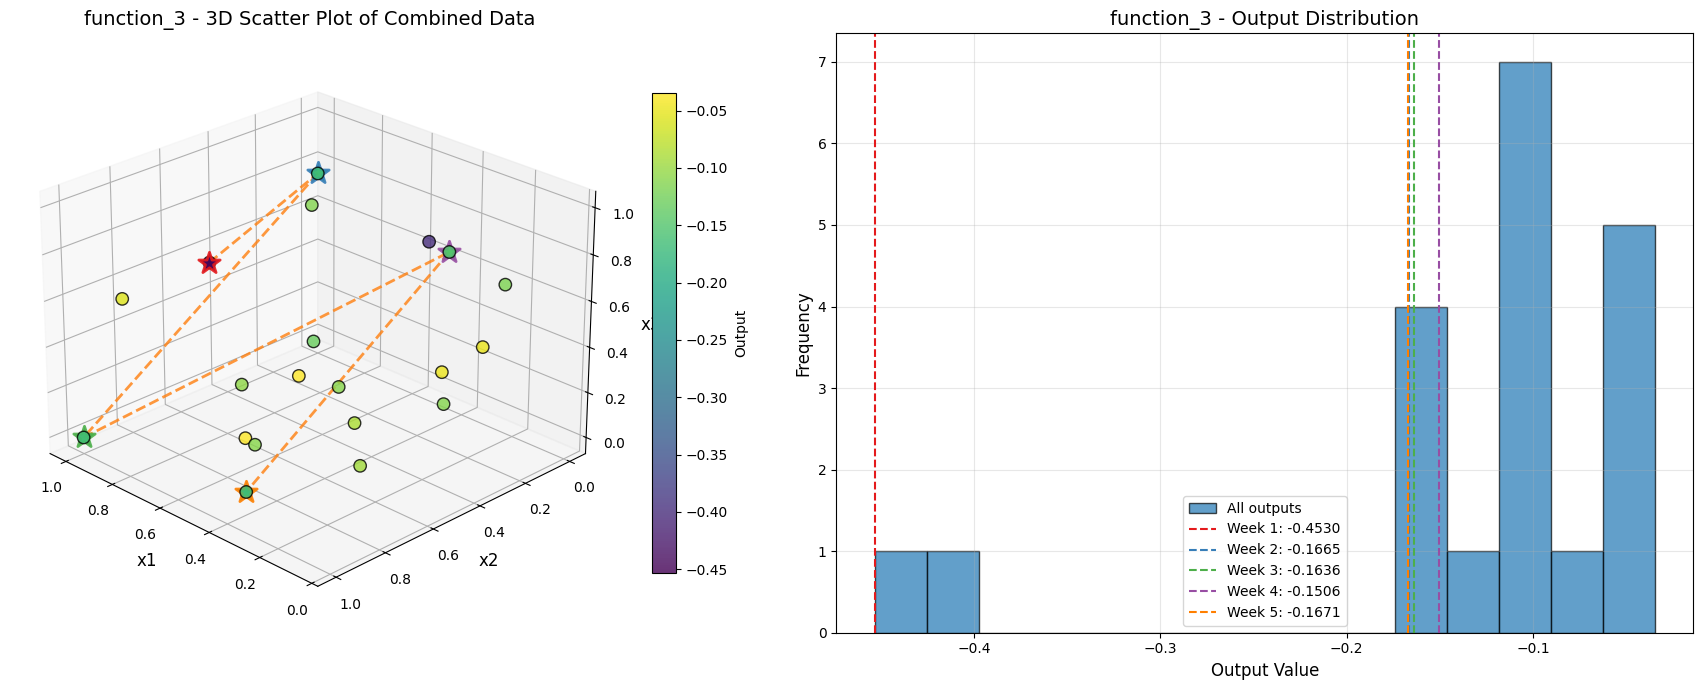

In [5]:
# Function 3 - Combine all data (initial + weeks 1-5)
function_name = 'function_3'

# Combine all observed data
X_observed = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1),
    week4_input.reshape(1, -1),
    week5_input.reshape(1, -1)
])
y_observed = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output]),
    np.array([week3_output]),
    np.array([week4_output]),
    np.array([week5_output])
])

# Validate progress
status, message, flag = validate_progress(y_observed, function_name)

print("=" * 60)
print("FUNCTION 3 - COMBINED DATA & VALIDATION")
print("=" * 60)
print(f"\nCombined inputs shape: {X_observed.shape}")
print(f"Combined outputs shape: {y_observed.shape}")
print(f"\nBest observed output so far: {y_observed.max():.6f}")
print(f"Mean output: {y_observed.mean():.6f}")
print(f"Std output: {y_observed.std():.6f}")
print(f"\n{'⚠️ ' if flag else '✓ '}PROGRESS STATUS: {status.upper()}")
print(f"  {message}")
print("=" * 60)

# Visualize: show all week 1–5 points
plot_3d_scatter_with_distribution(
    X_observed, y_observed,
    week5_input, week5_output,
    function_name,
    weekly_points=[
        (week1_input, week1_output, "Week 1"),
        (week2_input, week2_output, "Week 2"),
        (week3_input, week3_output, "Week 3"),
        (week4_input, week4_output, "Week 4"),
        (week5_input, week5_output, "Week 5"),
    ],
    connect_points=True,
    connect_color="tab:orange"
)


In [11]:
# Function 3 - Run Noise-aware Bayesian Optimization (same flow as function2_3_4_5_6 notebook)
function_name = 'function_3'
n_dims = X_observed.shape[1]
bounds = [[0.0, 1.0]] * n_dims

# Create noise-aware BO (WhiteKernel + local restarts; default beta=0.5 for noisy objectives)
bo = BayesianOptimizationForNoise(bounds=bounds, n_initial=0, random_state=42)

# Fit GP to observed data
bo.fit(X_observed, y_observed)

# Suggest next point (beta=0.5 default for noisy objectives)
next_point = bo.suggest_next_point(beta=0.5)
ucb_value = bo.acquisition_ucb(next_point.reshape(1, -1), beta=0.5)[0]

# Format for submission
formatted_point = '-'.join([f'{x:.6f}' for x in next_point])

print("\n" + "=" * 60)
print("FUNCTION 3 - NOISE-AWARE BO SUGGESTION (β=0.5)")
print("=" * 60)
print(f"Suggested next point: {formatted_point}")
print(f"Expected value (UCB with β=0.5): {ucb_value:.6f}")
if flag:
    print(f"\n⚠️  WARNING: {message}")
    print("   Consider exploring or checking surrogate model quality")
print("=" * 60)

# Save to JSON (same structure as function1_next_point)
result_json = {
    "function_name": function_name,
    "next_point": next_point.tolist(),
    "formatted": formatted_point,
    "method": "bayesian_optimization_for_noise",
}

output_path = 'results/function3_next_point.json'
with open(output_path, 'w') as f:
    json.dump(result_json, f, indent=2)

print(f"\nResult saved to: {output_path}")



FUNCTION 3 - NOISE-AWARE BO SUGGESTION (β=0.5)
Suggested next point: 0.000000-0.000000-0.853616
Expected value (UCB with β=0.5): 0.047849

⚠️  WARNING: Recent values declining! Best=-0.034835, Recent=-0.150550
   Consider exploring or checking surrogate model quality

Result saved to: results/function3_next_point.json


/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## Slice plots at incumbent best x*

Below we fix one input at the incumbent best value and plot the GP **mean**, **std**, and **acquisition (UCB)** over the other two dimensions. We overlay:
- **All observed points** (in the 2D projection of the slice)
- **Incumbent best point** x*
- **Suggested next point**

If the optimiser is searching around the maximum, the next point should lie in a high-acquisition region near the incumbent.

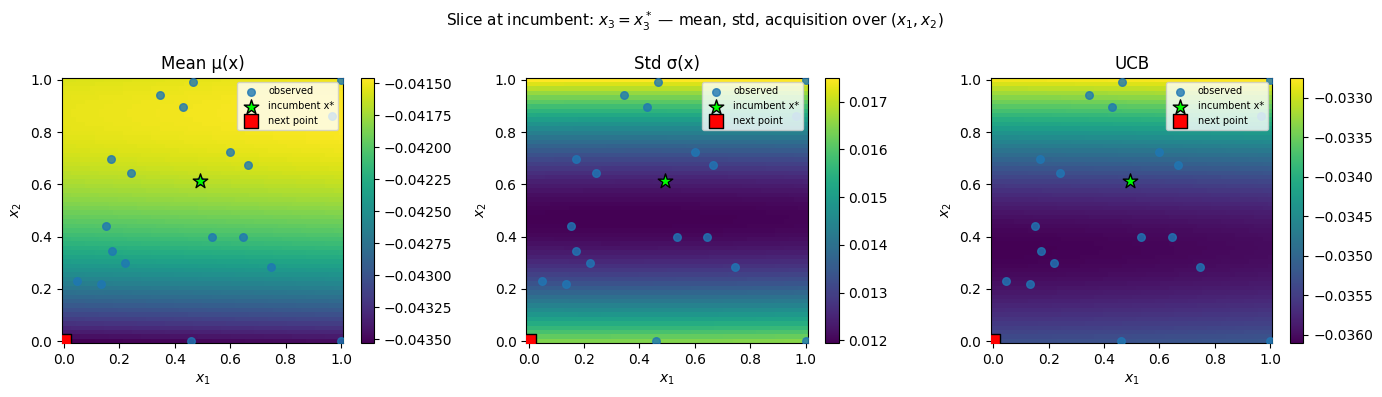

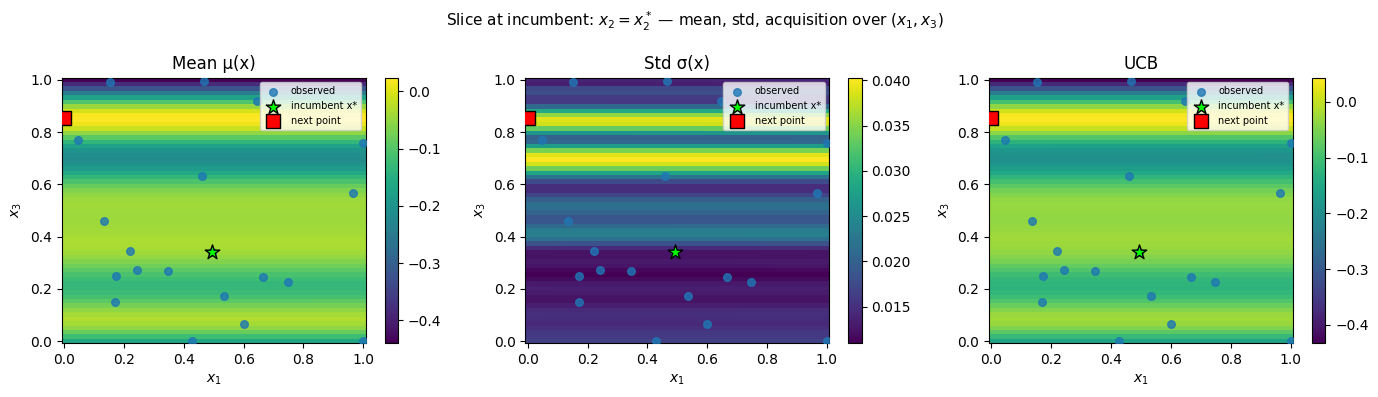

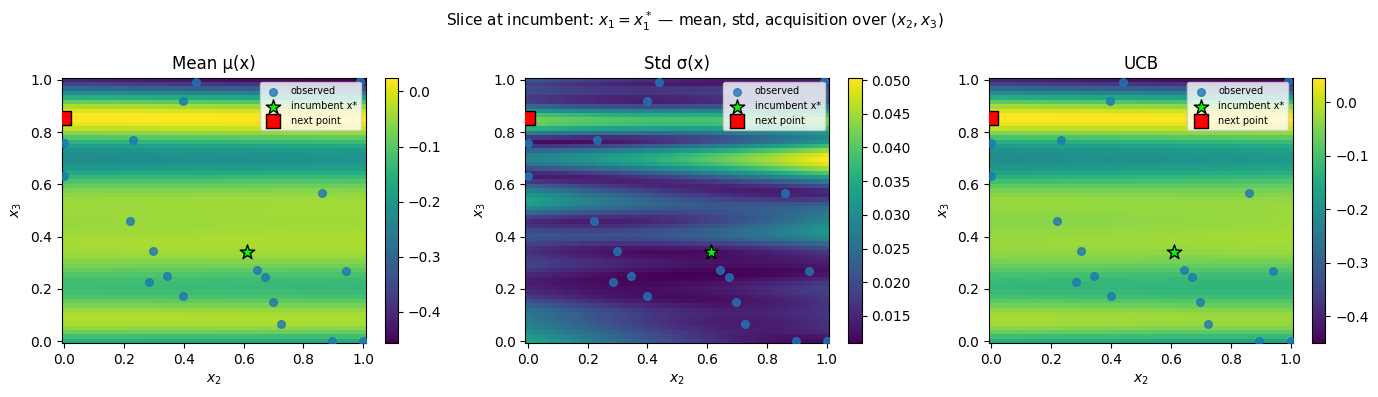

In [7]:
# Incumbent best and slice plot setup
x_star = X_observed[np.argmax(y_observed)]
beta_ucb = 0.5
ngrid = 60
bounds_arr = np.array(bounds)

def eval_slice(bo, x_star, varying_dims, fixed_dim, ngrid=60):
    """Build grid on 2D slice (fixed_dim = x_star[fixed_dim]), return mesh + mean, std, acquisition."""
    # varying_dims = (dim0, dim1) e.g. (0, 1) for (x1, x2)
    d0, d1 = varying_dims
    lo0, hi0 = bounds_arr[d0, 0], bounds_arr[d0, 1]
    lo1, hi1 = bounds_arr[d1, 0], bounds_arr[d1, 1]
    g0 = np.linspace(lo0, hi0, ngrid)
    g1 = np.linspace(lo1, hi1, ngrid)
    gg0, gg1 = np.meshgrid(g0, g1)
    # Full 3D points: fill in all three dims
    n_pts = gg0.size
    X = np.zeros((n_pts, 3))
    X[:, d0] = gg0.ravel()
    X[:, d1] = gg1.ravel()
    X[:, fixed_dim] = x_star[fixed_dim]
    mean, std = bo.predict(X)
    ucb = bo.acquisition_ucb(X, beta=beta_ucb)
    return gg0, gg1, mean.reshape(gg0.shape), std.reshape(gg0.shape), ucb.reshape(gg0.shape)

def plot_slice(ax_mean, ax_std, ax_acq, gg0, gg1, mean, std, ucb,
               X_obs, x_star, next_pt, varying_dims):
    d0, d1 = varying_dims
    for ax, data, label in [(ax_mean, mean, "Mean μ(x)"), (ax_std, std, "Std σ(x)"), (ax_acq, ucb, "UCB")]:
        im = ax.pcolormesh(gg0, gg1, data, shading="auto")
        plt.colorbar(im, ax=ax)
        ax.set_xlabel(f"$x_{d0+1}$")
        ax.set_ylabel(f"$x_{d1+1}$")
        ax.set_title(label)
    # Overlay: observed points (2D projection), incumbent, next point
    for ax in (ax_mean, ax_std, ax_acq):
        ax.scatter(X_obs[:, d0], X_obs[:, d1], c="tab:blue", s=30, alpha=0.8, label="observed", zorder=3)
        ax.scatter(x_star[d0], x_star[d1], c="lime", s=120, marker="*", edgecolors="black", label="incumbent x*", zorder=4)
        ax.scatter(next_pt[d0], next_pt[d1], c="red", s=100, marker="s", edgecolors="black", label="next point", zorder=4)
        ax.legend(loc="upper right", fontsize=7)

# 1) Fix x3 = x3*, plot over (x1, x2)
gg0_12, gg1_12, mean_12, std_12, ucb_12 = eval_slice(bo, x_star, (0, 1), 2, ngrid)
fig1, (ax1m, ax1s, ax1u) = plt.subplots(1, 3, figsize=(14, 4))
plot_slice(ax1m, ax1s, ax1u, gg0_12, gg1_12, mean_12, std_12, ucb_12,
           X_observed, x_star, next_point, (0, 1))
fig1.suptitle("Slice at incumbent: $x_3 = x_3^*$ — mean, std, acquisition over $(x_1, x_2)$", fontsize=11)
plt.tight_layout()
plt.show()

# 2) Fix x2 = x2*, plot over (x1, x3)
gg0_13, gg1_13, mean_13, std_13, ucb_13 = eval_slice(bo, x_star, (0, 2), 1, ngrid)
fig2, (ax2m, ax2s, ax2u) = plt.subplots(1, 3, figsize=(14, 4))
plot_slice(ax2m, ax2s, ax2u, gg0_13, gg1_13, mean_13, std_13, ucb_13,
           X_observed, x_star, next_point, (0, 2))
fig2.suptitle("Slice at incumbent: $x_2 = x_2^*$ — mean, std, acquisition over $(x_1, x_3)$", fontsize=11)
plt.tight_layout()
plt.show()

# 3) Fix x1 = x1*, plot over (x2, x3)
gg0_23, gg1_23, mean_23, std_23, ucb_23 = eval_slice(bo, x_star, (1, 2), 0, ngrid)
fig3, (ax3m, ax3s, ax3u) = plt.subplots(1, 3, figsize=(14, 4))
plot_slice(ax3m, ax3s, ax3u, gg0_23, gg1_23, mean_23, std_23, ucb_23,
           X_observed, x_star, next_point, (1, 2))
fig3.suptitle("Slice at incumbent: $x_1 = x_1^*$ — mean, std, acquisition over $(x_2, x_3)$", fontsize=11)
plt.tight_layout()
plt.show()

## Distance-to-incumbent plot

For each week \(t\), compute \(\|x_t - x^*\|\) (Euclidean distance from that week’s evaluated point to the incumbent best \(x^*\)). If distances are small every time, the strategy is **exploiting** (staying near the best). If they are large, it is **exploring**.

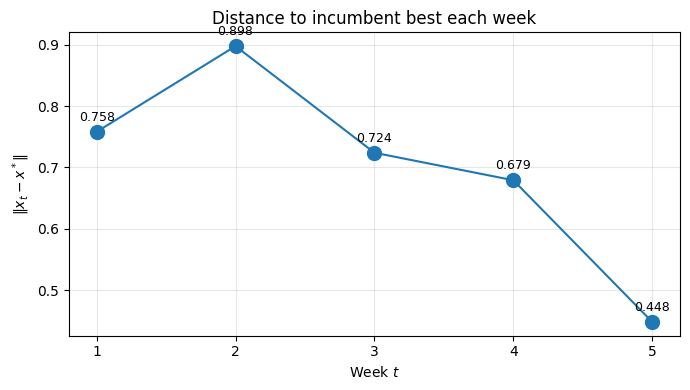

In [9]:
# Distance from each week's point to incumbent best x*
x_star = X_observed[np.argmax(y_observed)]
weekly_points = [
    (1, week1_input),
    (2, week2_input),
    (3, week3_input),
    (4, week4_input),
    (5, week5_input),
]
weeks = [w for w, _ in weekly_points]
distances = [np.linalg.norm(x_t - x_star) for _, x_t in weekly_points]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(weeks, distances, "o-", color="tab:blue", markersize=10)
ax.set_xlabel("Week $t$")
ax.set_ylabel(r"$\|x_t - x^*\|$")
ax.set_title("Distance to incumbent best each week")
ax.set_xticks(weeks)
ax.grid(True, alpha=0.3)
for w, d in zip(weeks, distances):
    ax.annotate(f"{d:.3f}", (w, d), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## Acquisition reason breakdown at the chosen point

UCB(x) = μ(x) + βσ(x). Below we print μ and σ at the **suggested next point** and at the **incumbent best** so we can see whether the new point was chosen mainly for **high predicted mean** (exploitation) or **high uncertainty** (exploration).

In [10]:
# UCB = μ + βσ; compare next point vs incumbent best
x_star = X_observed[np.argmax(y_observed)]
mu_next, sigma_next = bo.predict(next_point.reshape(1, -1))
mu_best, sigma_best = bo.predict(x_star.reshape(1, -1))
mu_next, sigma_next = float(mu_next[0]), float(sigma_next[0])
mu_best, sigma_best = float(mu_best[0]), float(sigma_best[0])
beta_ucb = 0.5
ucb_next = mu_next + beta_ucb * sigma_next
ucb_best = mu_best + beta_ucb * sigma_best

print("Acquisition breakdown (UCB = μ + βσ, β = 0.5)")
print("=" * 50)
print(f"  μ(next)   = {mu_next:.6f}")
print(f"  σ(next)   = {sigma_next:.6f}")
print(f"  μ(best)   = {mu_best:.6f}")
print(f"  σ(best)   = {sigma_best:.6f}")
print("=" * 50)
print(f"  UCB(next) = μ + βσ = {ucb_next:.6f}")
print(f"  UCB(best) = μ + βσ = {ucb_best:.6f}")
print()
if mu_next > mu_best and sigma_next <= sigma_best:
    print("→ Chosen mainly for higher predicted mean (exploitation).")
elif sigma_next > sigma_best and mu_next <= mu_best:
    print("→ Chosen mainly for higher uncertainty (exploration).")
elif mu_next > mu_best and sigma_next > sigma_best:
    print("→ Chosen for both higher mean and higher uncertainty (mixed).")
else:
    print("→ Next point has lower mean and lower/high σ; UCB is still higher due to βσ term (exploration).")

Acquisition breakdown (UCB = μ + βσ, β = 0.5)
  μ(next)   = 0.027068
  σ(next)   = 0.041563
  μ(best)   = -0.041673
  σ(best)   = 0.012428
  UCB(next) = μ + βσ = 0.047849
  UCB(best) = μ + βσ = -0.035459

→ Chosen for both higher mean and higher uncertainty (mixed).
